# Section 1: Introduction & Model Selection

### Introduction
In this project, I will model a car suspension system using a spring-mass system (mechanical oscillations). A car's suspension system is designed to reduce vibrations transmitted from the road to the car body to maintain smoothness and comfort for the riders. Suspension motion is governed by displacement, velocity, and acceleration, so I will model this using a second-order differential equation. The quarter-car model is commonly used for this because it represents the vertical dynamics of one wheel and one fourth of the car body mass. 

For this project, I will use a 2025 Toyota Camry SE as the real-world inspiration for the model. Toyota lists the vehicle's curb weight as 3,494 lbs, or 1,585 kg. Using the quarter-car model, the mass of one wheel assembly is about 396 kg.

### Governing Second-Order ODE

$$
m\frac{d^2 y}{dt^2} + c\frac{dy}{dt} + ky = 0
$$

where: 
- $m$ = mass (kg)
- $c$ = damping coefficient (N·s/m)
- $k$ = spring constant (N/m)
- $y(t)$ = displacement from equilibrium (m)

### Conversion to System of First-Order ODEs

Let:

- $y_1 = y$ = position
- $y_2 = \frac{dy}{dt}$ = velocity

Then:
$$\frac{dy_1}{dt}=y_2$$
$$\frac{dy_2}{dt}=-\frac{c}{m}y_2-\frac{k}{m}y_1$$

### Physical Meaning of each variable and parameter

- $y_1$ = verticle displacement of the car body
- $y_2$ = verticle velocity of the car body
- $\frac{dy_2}{dt}$ = verticle acceleration of the car body

# Section 2: Parameter Research & Justification

## Parameter Research:

For the model, I framed it as a quarter-car suspension model for a 2025 Toyota Camry SE (FWD). Toyota lists the 2025 Camry SE curb weight as 3,494 lb, which is about 1,585 kg. For a quarter-car model, we focus on one wheel/suspension corner and roughly one-fourth of the vehicle body mass, so that gives a representative body mass of about 396 kg for the simplified model. Quarter-car modeling is a standard simplification used for suspension analysis because it isolates the vertical motion of one wheel and the corresponding share of vehicle body mass.

### Parameter Table

| Parameter | Meaning | Value | Units | Source |
|---|---|---|---|---|
| \(m\) | Quarter-car mass | 396 | kg | Camry curb weight / 4 |
| \(c\) | Damping coefficient | 600 | N·s/m | Typical passenger-car damper |
| \(k\) | Spring stiffness | 20000 | N/m | Typical quarter-car suspension |
| \(y(0)\) | Initial displacement | 0.10 | m | 10 cm speed bump |
| \(y'(0)\) | Initial velocity | 0 | m/s | Starts from rest |

## Citations (APA)

$(m):$

2025 CAMRY. (n.d.). Retrieved April 29, 2026, from https://www.toyota.com/content/dam/toyota/brochures/pdf/2025/my25-camry-ebrochure.pdf

2025 Camry Product Information #Camry #Hybrid. (n.d.). Retrieved April 29, 2026, from https://attachments.priuschat.com/attachment-files/2024/04/249677_2025_Toyota_Camry_Product_Information.pdf

Edmunds. (2021). Edmunds. https://www.edmunds.com

$(k):$

Kong, Y. S., Abdullah, S., Schramm, D., & Singh, S. S. K. (2019). Determining optimal suspension system parameters for spring fatigue life using design of experiment. Mechanics & Industry, 20(6), 621. https://doi.org/10.1051/meca/2019062

$(c):$

Mahala,K.Manoj, Gadkari, P., & Deb,Anindya. (2025). www.designsociety.org. ICORD 09: Proceedings of the 2nd International Conference on Research into Design, Bangalore, India 07.-09.01.2009, 168–175. https://www.designsociety.org/publication/32277/mathematical_models_for_designing_vehicles_for_ride_comfort

$\text{General research on modeling car suspensions:}$

Control Tutorials for MATLAB and Simulink - Suspension: Simulink Modeling. (2026). Umich.edu. https://ctms.engin.umich.edu/CTMS/index.php?example=Suspension&section=SimulinkModeling&

### Initial Conditions

To simulate the car passing over a speed bump, I used an initial displacement of:
$$y(0)=0.1 \text{ m}$$
and an initial velocity of:
$$y'(0)=0 \text{ m/s}$$

These conditions show the car body initially displaced but not moving vertically. This creates a realistic damped vibration response where the suspension returns the car body to equilibrium over time. 

### Final Model with Values

$$396\frac{d^2y}{dt^2}+600\frac{dy}{dt}+20000y=0$$

Simplifies to:
$$\frac{d^2y}{dt^2}+1.51\frac{dy}{dt}+50.51y=0$$

The first-order system is:
$$y_1'=y_2$$
$$y_2'=-1.51y_2-50.51y_1$$

# Section 3: Numerical Methods Implementation

The suspension model is solved numerically using Euler's Forward Method and the fourth-order Runge-Kutta method (RK4). The second-order ODE was rewritten as a system of first-order equations:

$$y_1' = y_2$$

$$y_2' = -\frac{c}{m}y_2 - \frac{k}{m}y_1$$

The parameter values used are:

$$m = 396 \text{ kg}, c = 600 \text{ N·s/m}, k = 20000 \text{ N/m}$$

The initial conditions are:

$$y(0)=0.10 \text{ m}, \quad y'(0)=0 \text{ m/s}$$

In [10]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters and initial conditions
m = 396
c = 600
k = 20000
y0 = 0.1
v0 = 0

def suspension_system(t, Y):
    y1 = Y[0]
    y2 = Y[1]
    dy1dt = y2
    dy2dt = -(c/m)*y2-(k/m)*y1
    
    return np.array([dy1dt, dy2dt])

#time setup
t0 = 0
tf = 8
h = 0.01 #step size

def forward_euler(f, Y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    Y_values = np.zeros((len(t_values), len(Y0)))
    Y_values[0] = Y0
    
    for i in range(1, len(t_values)):
        Y_values[i] = Y_values[i-1] + h * f(t_values[i-1], Y_values[i-1])
        
    return t_values, Y_values

def rk4(f, Y0, t0, tf, h):
    # Create an array for time steps
    t_values = np.arange(t0, tf + h, h)
    Y_values = np.zeros((len(t_values), len(Y0)))
    # Set the initial condition
    Y_values[0] = Y0
    # Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        Y = Y_values[i - 1]        
        k1 = h * f(t, Y)
        k2 = h * f(t + h / 2, Y + k1 / 2)
        k3 = h * f(t + h / 2, Y + k2 / 2)
        k4 = h * f(t + h, Y + k3)        
        # Update Y based on the RK4 formula
        Y_values[i] = Y + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return t_values, Y_values

#Run both methods
Y0 = np.array([y0, v0])

t_euler, Y_euler = forward_euler(suspension_system, Y0, t0, tf, h)
t_rk4, Y_rk4 = rk4(suspension_system, Y0, t0, tf, h)

y_euler = Y_euler[:, 0]
v_euler = Y_euler[:, 1]

y_rk4 = Y_rk4[:, 0]
v_rk4 = Y_rk4[:, 1]

### Explanation of implemented approach

Euler's Forward Method and RK4 were used to approximate the motion of the suspension system. Euler's method estimates the next point using the slope at the beginning of each step. RK4 uses four slope estimates which produces a more accurate approximation.

The displacement plot shows how the suspension oscillates and gradually returns toward equilibrium from damping. The velocity plot shows how the vertical speed of the car body changes and reduces over time. The phase plot shows the relationship between displacement and velocity. The spiral shape indicates that the system loses energy over time because of damping.

# Section 4: Solutions & Comparison

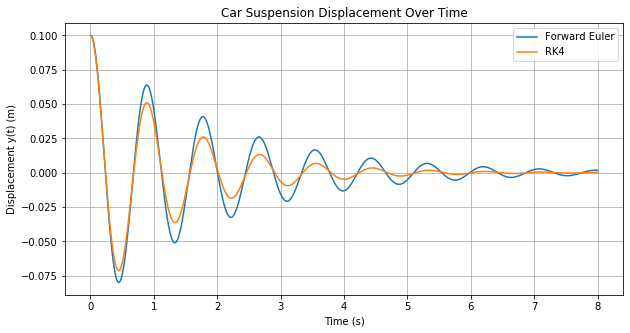

In [11]:
#Plot displacement
plt.figure(figsize=(10, 5))
plt.plot(t_euler, y_euler, label="Forward Euler")
plt.plot(t_rk4, y_rk4, label="RK4")
plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("Car Suspension Displacement Over Time")
plt.legend()
plt.grid(True)
plt.show()

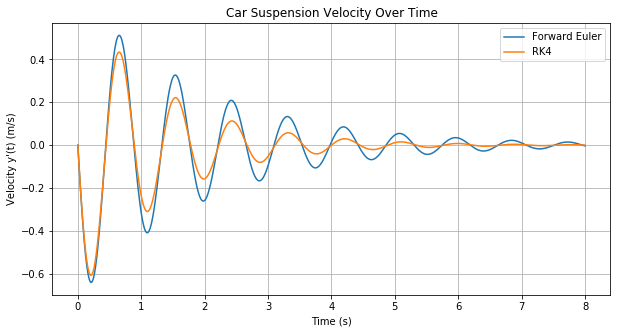

In [12]:
#Plot velocity
plt.figure(figsize=(10, 5))
plt.plot(t_euler, v_euler, label="Forward Euler")
plt.plot(t_rk4, v_rk4, label="RK4")
plt.xlabel("Time (s)")
plt.ylabel("Velocity y'(t) (m/s)")
plt.title("Car Suspension Velocity Over Time")
plt.legend()
plt.grid(True)
plt.show()

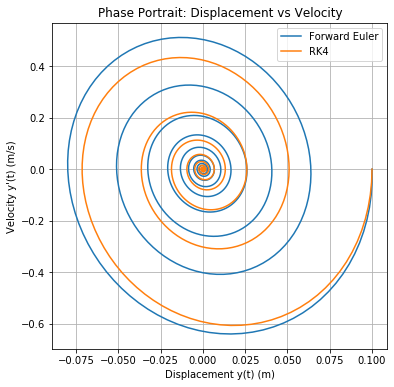

In [13]:
#Phase portrait
plt.figure(figsize=(6, 6))
plt.plot(y_euler, v_euler, label="Forward Euler")
plt.plot(y_rk4, v_rk4, label="RK4")
plt.xlabel("Displacement y(t) (m)")
plt.ylabel("Velocity y'(t) (m/s)")
plt.title("Phase Portrait: Displacement vs Velocity")
plt.legend()
plt.grid(True)
plt.show()

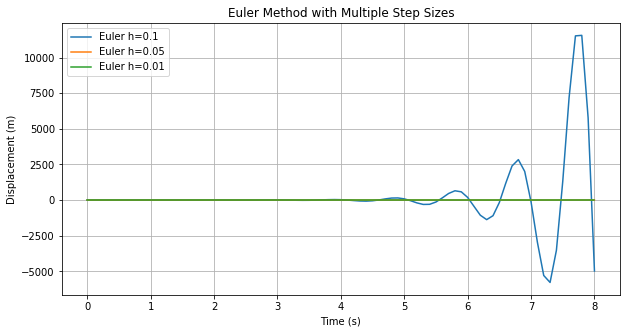

In [14]:
#Multiple step sizes comparison - Euler
h_values = [0.1, 0.05, 0.01]

plt.figure(figsize=(10,5))

for h in h_values:
    t_euler, Y_euler = forward_euler(suspension_system, Y0, t0, tf, h)
    plt.plot(t_euler, Y_euler[:,0], label=f"Euler h={h}")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Euler Method with Multiple Step Sizes")
plt.legend()
plt.grid(True)
plt.show()

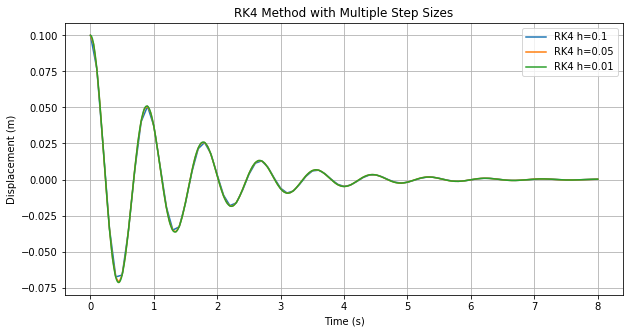

In [15]:
#Multiple step sizes comparison - RK4
plt.figure(figsize=(10,5))

for h in h_values:
    t_rk4, Y_rk4 = rk4(suspension_system, Y0, t0, tf, h)
    plt.plot(t_rk4, Y_rk4[:,0], label=f"RK4 h={h}")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("RK4 Method with Multiple Step Sizes")
plt.legend()
plt.grid(True)
plt.show()

### Discussion of visual differences between methods

Both numerical methods captured the damped oscillatory motion of the suspension system. The displacement and velocity plots show that the car body oscillates after the bump and gradually returns to equilibrium due to damping.

The phase portrait forms an inward spiral, indicating energy loss over time.

When multiple step sizes were tested, Euler's Forward Method became less accurate for larger step sizes. RK4 remained much more consistent and accurate across all tested step sizes.

Overall, RK4 provided the best performance for this suspension model.

# Section 5: Stability Analysis

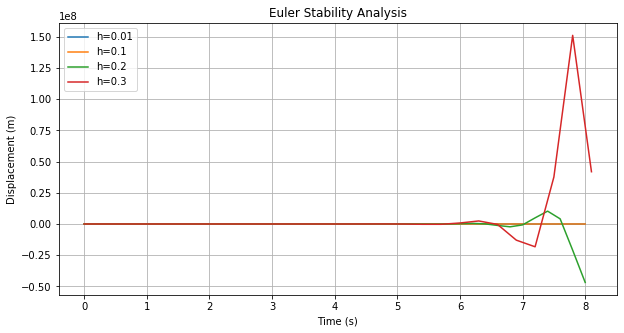

In [16]:
#Stability Analysis - Euler
h_values = [0.01, 0.1, 0.2, 0.3]

plt.figure(figsize=(10,5))

for h in h_values:
    t_temp, Y_temp = forward_euler(suspension_system, Y0, t0, tf, h)
    plt.plot(t_temp, Y_temp[:,0], label=f"h={h}")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Euler Stability Analysis")
plt.legend()
plt.grid(True)
plt.show()

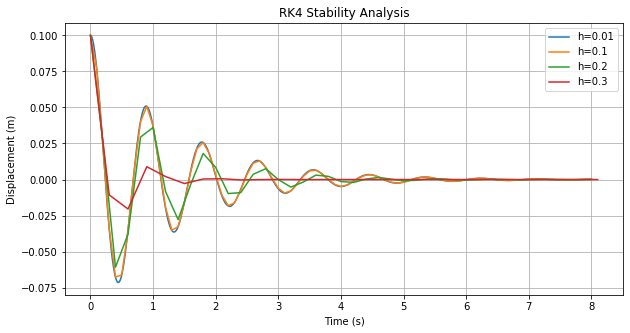

In [17]:
#Stability Analysis - RK4
plt.figure(figsize=(10,5))

for h in h_values:
    t_temp, Y_temp = rk4(suspension_system, Y0, t0, tf, h)
    plt.plot(t_temp, Y_temp[:,0], label=f"h={h}")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("RK4 Stability Analysis")
plt.legend()
plt.grid(True)
plt.show()

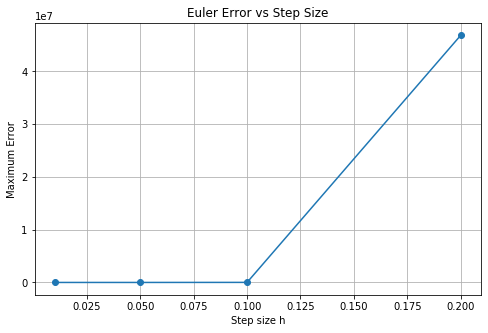

In [18]:
#RK4 at h=0.001 used as reference
t_ref, Y_ref = rk4(suspension_system, Y0, t0, tf, 0.001)
y_ref = Y_ref[:,0]

#Error Analysis Plot
errors = []
h_vals = [0.01, 0.05, 0.1, 0.2]

for h in h_vals:
    t_temp, Y_temp = forward_euler(suspension_system, Y0, t0, tf, h)
    y_interp = np.interp(t_temp, t_ref, y_ref)
    err = np.max(np.abs(Y_temp[:,0] - y_interp))
    errors.append(err)

plt.figure(figsize=(8,5))
plt.plot(h_vals, errors, marker='o')
plt.xlabel("Step size h")
plt.ylabel("Maximum Error")
plt.title("Euler Error vs Step Size")
plt.grid(True)
plt.show()

### Stability Analysis

The damped suspension system should physically lose energy and return to equilibrium after the initial bump. Numerical methods should reproduce this behavior when stable.

For Euler's Forward Method, small step sizes such as h=0.01 produced realistic damped oscillations. But as the step size increased, the solution became less accurate and unstable. Large step sizes caused oscillations to grow instead of decay.

RK4 remained stable over a much wider range of step sizes and continued to capture the expected damped response.

This proves that Euler's method has stricter stability limits, while RK4 provides better stability and accuracy for these systems.

### Physical Interpretation of Results

An unstable numerical solution would mean that the car suspension gains energy after hitting a bump, causing the car to bounce more over time. Since this is impossible for a damped system, this behavior indicates numerical instability rather than real motion.

# Section 6: Conclusions

For my car suspension model, the fourth-order Runge-Kutta method performed better overall than Euler's Forward Method. RK4 produced more accurate results in several different areas and remained stable for larger step sizes. On the other hand, Euler's method produced larger numerical error and became unstable as the step size grew too large. With the system being oscillatory and damped, it is important that I needed an accurate method to track the amplitude and decay behavior, and RK4 did a much better job at handling it.

There is a tradeoff between computational cost and accuracy. Euler's method only requires one function to be evaluated at each step, so it is faster and simpler to implement. RK4, however, requires four function evaluations per step, so each step has a higher computational cost. RK4 is still more efficient overall, despite its higher computational cost, because it can use larger step sizes while still maintaining high accuracy.

For practical engineering simulations which involve second-order systems, such as suspension, vibrations, etc. RK4 is the most accurate method. Euler's method can be useful to learn numerical methods and for quick approximations and simple problems, however for practical models, it is best to use RK4.

I have learned from this project that my choice of numerical method is an extremely important part of analysis and can significantly affect the results and outcomes. A poor method or step size can cause behavior that is physically impossible or not accurate, such as growing oscillations in my damped system. I have found that there are tradeoffs to each method and the key is to balance efficiency, stability, and accuracy when choosing a method for real-world engineering applications.